11:08:00 - cmdstanpy - INFO - Chain [1] start processing
11:08:00 - cmdstanpy - INFO - Chain [1] done processing
11:08:00 - cmdstanpy - INFO - Chain [1] start processing



=== VAL (2024-07..12) — RF (direct, specified features) ===
MAE: 18.46 | RMSE: 35.04 | MAPE: 7.08%


11:08:01 - cmdstanpy - INFO - Chain [1] done processing



=== TEST (2025-01..07) — RF (Auto-Exog, Recursive, specified features) ===
MAE: 55.91 | RMSE: 78.67 | MAPE: 52.46%


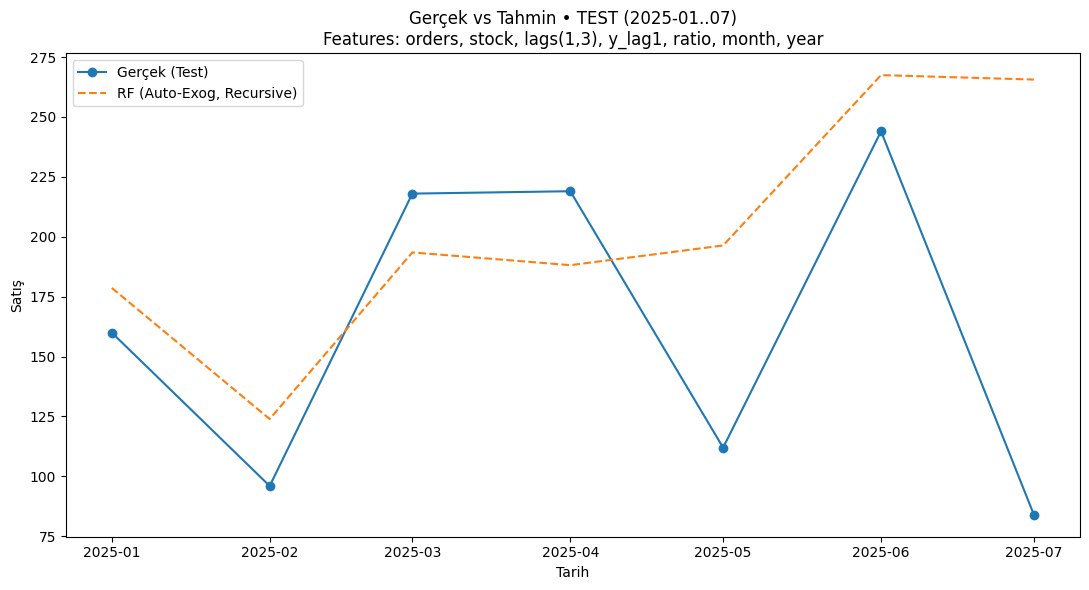


[Özellik örnek satırları — recursive kullanılan çerçeve]
        ds          y     orders      stock  orders_lag1  orders_lag3  stock_lag1  stock_lag3     y_lag1  orders_ratio  month  year
2025-01-01 178.661709 239.656497 129.315352    56.000000    84.000000  167.000000  216.000000  56.000000      1.853272      1  2025
2025-02-01 123.938000 144.873512  67.691488   239.656497   128.000000  129.315352  127.000000 178.661709      2.140203      2  2025
2025-03-01 193.461005 261.173809  64.560535   144.873512    56.000000   67.691488  167.000000 123.938000      4.045410      3  2025
2025-04-01 188.147663 210.039192 170.442752   261.173809   239.656497   64.560535  129.315352 193.461005      1.232315      4  2025
2025-05-01 196.358294 243.386838 153.396888   210.039192   144.873512  170.442752   67.691488 188.147663      1.586648      5  2025


In [2]:
# ==============================================================
# RF (direct) with EXACT feature set + Auto-Exog (orders/stock via Prophet)
# Features: orders, stock, orders_lag1, orders_lag3,
#           stock_lag1, stock_lag3, y_lag1, orders_ratio, month, year
# ==============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

# ------------------ Config ------------------
CSV_PATH   = "veri_matrisi_final_sales_orders_stock_calendar_lags_fx.csv"

TRAIN_END  = pd.Timestamp("2024-12-01")
VAL_START  = pd.Timestamp("2024-07-01")
VAL_END    = pd.Timestamp("2024-12-01")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END   = pd.Timestamp("2025-07-01")

RANDOM_STATE = 42

# Kullanılacak ÖZELLİKLER (tam liste)
X_FEATURES = [
    "orders","stock",
    "orders_lag1","orders_lag3",
    "stock_lag1","stock_lag3",
    "y_lag1",
    "orders_ratio",
    "month","year",
]

# ------------------ Helpers ------------------
def mae_rmse_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(y_true == 0, 1, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    return mae, rmse, mape

def ensure_ms_freq(df):
    """Aylık (MS) frekans; ay başına yuvarlayıp index.freq='MS' atar (eksik ayları doldurmaz)."""
    d = df.copy().sort_values("ds")
    d["ds"] = d["ds"].dt.to_period("M").dt.to_timestamp(how="start")
    d = d.set_index("ds").sort_index()
    d.index = pd.DatetimeIndex(d.index, freq="MS")
    return d.reset_index()

def add_calendar(df):
    d = df.copy()
    d["year"] = d["ds"].dt.year
    d["month"] = d["ds"].dt.month
    return d

def build_lags_minimal(df):
    """Sadece: y_lag1, orders_lag1/3, stock_lag1/3 ve orders_ratio üretir."""
    d = df.copy()
    if "orders" in d.columns and "stock" in d.columns:
        d["orders_ratio"] = d["orders"] / d["stock"].replace(0, np.nan)
    # y_lag1
    if "y" in d.columns:
        d["y_lag1"] = d["y"].shift(1)
    # orders lag1/lag3
    if "orders" in d.columns:
        d["orders_lag1"] = d["orders"].shift(1)
        d["orders_lag3"] = d["orders"].shift(3)
    # stock lag1/lag3
    if "stock" in d.columns:
        d["stock_lag1"] = d["stock"].shift(1)
        d["stock_lag3"] = d["stock"].shift(3)
    return d

def forecast_exog_prophet(series_df, col_name, future_ds):
    """
    Tek kolonluk seri (ds, value) için Prophet ile forward tahmin.
    series_df: ['ds', col_name] (aylık MS)
    future_ds: ileri tarihlerin ds (DatetimeIndex)
    """
    s = series_df[["ds", col_name]].dropna().copy().sort_values("ds")
    if s.empty:
        # hiç veri yoksa 0 dön
        return pd.DataFrame({"ds": future_ds, col_name: 0.0})
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False)
    m.fit(s.rename(columns={col_name:"y"}))
    last_known = s["ds"].max()
    horizon = max(0, (max(future_ds) - last_known).days // 30 + 1)
    fut = m.make_future_dataframe(periods=horizon, freq="MS")
    fc = m.predict(fut)[["ds","yhat"]]
    fc_needed = fc[fc["ds"].isin(pd.DatetimeIndex(future_ds))].copy()
    fc_needed = fc_needed.rename(columns={"yhat": col_name})
    # Prophet seçmedi ise (ör. horizon=0) boş gelebilir → sıfırla
    if fc_needed.empty:
        fc_needed = pd.DataFrame({"ds": future_ds, col_name: 0.0})
    return fc_needed[["ds", col_name]]

def recursive_forward_predict_rf(df_hist, model, x_cols, start_ds, end_ds, future_exog):
    """
    df_hist: geçmiş (ds,y,orders,stock + calendar)
    future_exog: ileri aylar için exog (ds,orders,stock) — burada sadece bu ikisi şart.
    """
    hist = df_hist.sort_values("ds").copy()
    future_idx = pd.date_range(start_ds, end_ds, freq="MS")
    future_rows = pd.DataFrame({"ds": future_idx}).merge(future_exog, on="ds", how="left")

    # Geçmiş + gelecek
    full = pd.concat([hist, future_rows], ignore_index=True, sort=False)
    full = add_calendar(full)

    # Güvenlik: eksik kolonları ekle
    for col in ["orders","stock"]:
        if col not in full.columns: full[col] = 0.0

    preds = []
    for ds in future_idx:
        # Her adım öncesi minimum lag setini üret
        full = full.sort_values("ds").reset_index(drop=True)
        full = full.drop(columns=[c for c in full.columns if c.endswith("_lag1") or c.endswith("_lag3") or c=="orders_ratio"], errors="ignore")
        full = build_lags_minimal(full)

        # X kolonlarının tam olduğundan emin ol
        for col in x_cols:
            if col not in full.columns:
                full[col] = 0.0

        row = full.loc[full["ds"] == ds].copy()
        row = row.replace([np.inf, -np.inf], np.nan).fillna(0)

        X = row[x_cols].to_numpy()
        y_hat = model.predict(X)[0]
        preds.append({"ds": ds, "yhat": y_hat})

        # autoregressive güncelle
        full.loc[full["ds"] == ds, "y"] = y_hat
        # exogları ffill/bfill ile güvence altına al (forecast gelmemişse)
        full[["orders","stock"]] = full[["orders","stock"]].ffill().bfill()

    future_pred = pd.DataFrame(preds)
    used = full[full["ds"].isin(future_idx)].copy()
    return future_pred, used

# ------------------ Load ------------------
df = pd.read_csv(CSV_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
for c in ["y","orders","stock"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = ensure_ms_freq(df)
df = add_calendar(df)
df = build_lags_minimal(df)

# ------------------ Splits ------------------
mask_train_full = (df["ds"] <= TRAIN_END)
mask_val        = (df["ds"] >= VAL_START) & (df["ds"] <= VAL_END)
mask_test       = (df["ds"] >= TEST_START) & (df["ds"] <= TEST_END)

train_full = df.loc[mask_train_full].copy()
val_df     = df.loc[mask_val].copy()
test_df    = df.loc[mask_test].copy()

# ------------------ Train RF (direct) ------------------
# Eğitimde sadece belirtilen X_FEATURES kullanılacak
def prep_feats(df_in):
    d = add_calendar(df_in)
    d = build_lags_minimal(d)
    d = d.replace([np.inf, -np.inf], np.nan).fillna(0)
    # Olmayan kolonları ekle (sıfırla)
    for col in X_FEATURES:
        if col not in d.columns:
            d[col] = 0.0
    return d

train_feats = prep_feats(train_full)
val_feats   = prep_feats(val_df)

X_train = train_feats[X_FEATURES].copy()
y_train = train_feats["y"].copy()
X_val   = val_feats[X_FEATURES].copy()
y_val   = val_feats["y"].copy()

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# VAL evaluation (doğrudan)
val_pred = rf.predict(X_val)
mae_v, rmse_v, mape_v = mae_rmse_mape(y_val, val_pred)
print("\n=== VAL (2024-07..12) — RF (direct, specified features) ===")
print(f"MAE: {mae_v:.2f} | RMSE: {rmse_v:.2f} | MAPE: {mape_v:.2f}%")

# ------------------ Live-like TEST: exog yok → exog-forecast + recursive ------------------
future_idx = pd.date_range(TEST_START, TEST_END, freq="MS")

# orders/stock için Prophet forecast
exog_fc = pd.DataFrame({"ds": future_idx})
for col in ["orders","stock"]:
    if col in df.columns:
        fc = forecast_exog_prophet(df[["ds", col]], col, future_idx)
        exog_fc = exog_fc.merge(fc, on="ds", how="left")
    else:
        exog_fc[col] = 0.0

# Recursive için geçmiş (TRAIN_FULL + VAL) gerçekleri (y ve mevcut exog)
hist_for_recursive = df[df["ds"] < TEST_START][["ds","y","orders","stock","month","year"]].copy()

# ÇAĞRI
future_pred, used = recursive_forward_predict_rf(
    df_hist=hist_for_recursive,
    model=rf,
    x_cols=X_FEATURES,
    start_ds=TEST_START,
    end_ds=TEST_END,
    future_exog=exog_fc  # ileri aylar için orders/stock tahminleri
)

# TEST karşılaştırma
test_truth = test_df[["ds","y"]].copy()
test_eval = test_truth.merge(future_pred, on="ds", how="left")
mae_t, rmse_t, mape_t = mae_rmse_mape(test_eval["y"], test_eval["yhat"])
print("\n=== TEST (2025-01..07) — RF (Auto-Exog, Recursive, specified features) ===")
print(f"MAE: {mae_t:.2f} | RMSE: {rmse_t:.2f} | MAPE: {mape_t:.2f}%")

# ------------------ Plot ------------------
plt.figure(figsize=(11,6))
plt.plot(test_eval["ds"], test_eval["y"], "o-", label="Gerçek (Test)")
plt.plot(test_eval["ds"], test_eval["yhat"], "--", label="RF (Auto-Exog, Recursive)")
plt.title("Gerçek vs Tahmin • TEST (2025-01..07)\nFeatures: orders, stock, lags(1,3), y_lag1, ratio, month, year")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
plt.show()

# ------------------ Bilgi amaçlı: kullanılan özelliklerin bir örneği ------------------
print("\n[Özellik örnek satırları — recursive kullanılan çerçeve]")
show_cols = ["ds","y","orders","stock","orders_lag1","orders_lag3","stock_lag1","stock_lag3","y_lag1","orders_ratio","month","year"]
print(used[show_cols].head().to_string(index=False))
